# My backtest was a gauge that had never passed GR&R

In semiconductor quality you do not run a capability study on a gauge that has not passed
measurement-system analysis. If the instrument is biased, every Cpk you compute afterwards is a
confident statement about nothing.

In software research, almost nobody does MSA at all. The backtest engine **is** the gauge — it is
the thing standing between a price series and every number you will ever believe — and it ships
unvalidated, because it produces plausible output and nobody diffs plausible output against reality.

This notebook audits my own trading engine the way I would audit a production gauge: compare every
recorded fill against **the order the book actually intended to place**. That comparison is the
whole audit, and it takes one afternoon.

Data: `data/gauge_trades.csv` — 163 spot BUY trades from 13 live LLM-signal paper books, each row
carrying the stop-loss and take-profit that book had configured. Paper trading throughout; no real money.

In [1]:
import json, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = pathlib.Path.cwd().parent
t = pd.read_csv(ROOT / "data" / "gauge_trades.csv")

STOP_SLIP_PCT = 0.3     # a stop-MARKET order slips past its trigger. 0.3% on a liquid alt.

print(f"{len(t)} spot BUY trades · {t.book.nunique()} books · {t.entry_date.min()[:10]} → {t.exit_date.max()[:10]}")
t.exit_reason.value_counts().to_frame("n")

163 spot BUY trades · 13 books · 2026-05-13 → 2026-07-12


,n
exit_reason,
signal_reversal,94
stop_loss,47
take_profit,20
manual_close,2


## 1 · The naive read

Straight off the instrument, the book lost money and the stops look catastrophic. A −12% stop
realising a −27.7% worst case is the kind of number that makes you rewrite the strategy.

Before rewriting anything: **is the instrument telling the truth?**

In [2]:
t["fee"] = t.cost_usd * t.fee_pct / 100 * 2      # round-trip
net_recorded = t.pnl_usd_recorded.sum() - t.fee.sum()

naive = (t.groupby("exit_reason")
          .agg(n=("pnl_pct_recorded", "size"),
               mean_pct=("pnl_pct_recorded", "mean"),
               worst_pct=("pnl_pct_recorded", "min"),
               usd=("pnl_usd_recorded", "sum"))
          .round(2).sort_values("usd"))
print(f"net as recorded (incl. ${t.fee.sum():,.0f} fees): ${net_recorded:,.0f}\n")
naive

net as recorded (incl. $409 fees): $-2,548



,n,mean_pct,worst_pct,usd
exit_reason,,,,
stop_loss,47,-10.74,-27.70,-4166.76
signal_reversal,94,-0.48,-11.96,-527.61
manual_close,2,9.93,-0.01,99.38
take_profit,20,15.89,10.24,2455.43


## 2 · Calibrating the gauge

The engine closed **both** stops and take-profits at whatever price it observed on its *next poll*.
That is not how either order behaves in the real world:

- A **stop** rests on the exchange and triggers *intrabar*. Price gaps through it between polls, so
  the recorded loss is worse than the order could have suffered. **Pessimistic.**
- A **limit sell** (take-profit) fills *at* the limit and **never above it**. Booking +18% on a +15%
  order is money that does not exist. **Optimistic.**

Same line of code. Two biases, pointing opposite ways.

In [3]:
def corrected(r):
    """What the fill SHOULD have been, given the order the book actually placed."""
    if r.exit_reason == "stop_loss":
        # Stocks gap overnight — we cannot prove an escape at the stop, so keep the worse
        # observed price. Crypto trades continuously: a stop at X fills at ~X less slippage.
        if r.asset_type == "stock":
            return r.pnl_pct_recorded
        return max(r.pnl_pct_recorded, -r.cfg_stop_loss_pct - STOP_SLIP_PCT)
    if r.exit_reason == "take_profit":
        return min(r.pnl_pct_recorded, r.cfg_take_profit_pct)   # a limit fills AT the limit
    return r.pnl_pct_recorded                                    # market exits unchanged

t["pnl_pct_corrected"] = t.apply(corrected, axis=1)
t["pnl_usd_corrected"] = t.cost_usd * t.pnl_pct_corrected / 100

cmp = (t[t.exit_reason.isin(["stop_loss", "take_profit"])]
       .groupby("exit_reason")
       .apply(lambda g: pd.Series({
           "n": len(g),
           "order placed": (-g.cfg_stop_loss_pct.mean() if g.name == "stop_loss"
                            else g.cfg_take_profit_pct.mean()),
           "gauge recorded": g.pnl_pct_recorded.mean(),
           "corrected fill": g.pnl_pct_corrected.mean(),
       }), include_groups=False).round(2))
cmp

,n,order placed,gauge recorded,corrected fill
exit_reason,,,,
stop_loss,47.0,-7.47,-10.74,-8.09
take_profit,20.0,13.35,15.89,13.35


There it is. **Stops record worse than the order placed; take-profits record better.**

This is the part worth carrying away. A gauge with *one* bias is easy to catch: the mean drifts and
something looks wrong. A gauge biased in **two directions at once** produces a plausible net, a
plausible equity curve, and two badly wrong tails. It passes every sniff test you would think to
apply — because the errors are busy cancelling each other in exactly the statistic you are checking.

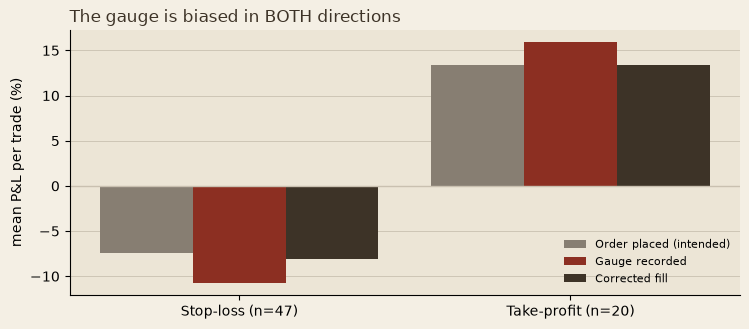

In [4]:
INK, INK_FAINT, RUBRIC = "#3d3327", "#877e72", "#8c2f22"
PAPER, PAPER_DEEP, HAIR = "#f4efe4", "#ece5d6", "#c9c0b0"

fig, ax = plt.subplots(figsize=(7.6, 3.4), facecolor=PAPER)
x, w = np.arange(2), 0.28
ax.bar(x - w, cmp["order placed"],   w, color=INK_FAINT, label="Order placed (intended)")
ax.bar(x,     cmp["gauge recorded"], w, color=RUBRIC,    label="Gauge recorded")
ax.bar(x + w, cmp["corrected fill"], w, color=INK,       label="Corrected fill")
ax.axhline(0, color=HAIR, lw=1)
ax.set_xticks(x); ax.set_xticklabels([f"Stop-loss (n={int(cmp.n.iloc[0])})",
                                      f"Take-profit (n={int(cmp.n.iloc[1])})"])
ax.set_ylabel("mean P&L per trade (%)"); ax.set_facecolor(PAPER_DEEP)
ax.set_title("The gauge is biased in BOTH directions", loc="left", color=INK)
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="lower right"); ax.grid(axis="y", color=HAIR, lw=.6)
ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 3 · Recalibrating did not save the result. It made it readable.

Correcting the fills moves the book — but it does **not** rescue it. That distinction matters more
than the dollars: a calibrated gauge does not make a bad process good. It makes the badness *legible*.

In [5]:
net_corrected = t.pnl_usd_corrected.sum() - t.fee.sum()
artifact = net_corrected - net_recorded

wins = t.pnl_pct_corrected[t.pnl_pct_corrected > 0]
loss = t.pnl_pct_corrected[t.pnl_pct_corrected <= 0]
win_rate = len(wins) / len(t)
payoff = wins.mean() / abs(loss.mean())
breakeven = (1 - win_rate) / win_rate

print(f"net as recorded : ${net_recorded:>8,.0f}")
print(f"net corrected   : ${net_corrected:>8,.0f}")
print(f"gauge artifact  : ${artifact:>8,.0f}   <- manufactured by the instrument, not the market\n")
print(f"win rate        : {win_rate*100:.1f}%")
print(f"payoff ratio    : {payoff:.2f}")
print(f"payoff NEEDED   : {breakeven:.2f}   <- to merely break even at that win rate")
print(f"\nverdict: {'LOSING BY ARITHMETIC' if payoff < breakeven else 'viable'}")

net as recorded : $  -2,548
net corrected   : $  -1,856
gauge artifact  : $     692   <- manufactured by the instrument, not the market

win rate        : 39.9%
payoff ratio    : 1.13
payoff NEEDED   : 1.51   <- to merely break even at that win rate

verdict: LOSING BY ARITHMETIC


**A 39.9% win rate needs a payoff ratio of 1.51 to break even. It had 1.13.**

The system was losing *by arithmetic*. No improvement in signal quality could have saved it — and
that diagnosis was unreadable while the gauge was distorting both tails.

The cause is structural: the take-profit capped winners at +10–15% while the stops let losers run
past their level. Winners cut short, losers left long — the precise inverse of what any system with
a fat-tailed payoff requires.

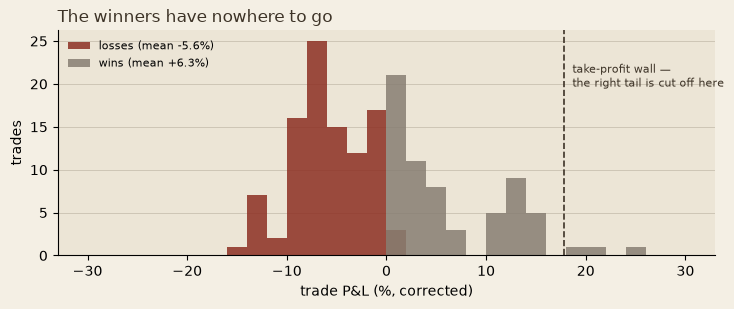

In [6]:
# Where does a trend system's money actually live? In the right tail — which is exactly
# what a take-profit amputates. Compare the shape of wins vs losses.
fig, ax = plt.subplots(figsize=(7.6, 3.2), facecolor=PAPER)
bins = np.arange(-30, 31, 2)
ax.hist(loss, bins=bins, color=RUBRIC,    alpha=.85, label=f"losses (mean {loss.mean():+.1f}%)")
ax.hist(wins, bins=bins, color=INK_FAINT, alpha=.85, label=f"wins (mean {wins.mean():+.1f}%)")
ax.axvline(t.cfg_take_profit_pct.mean(), color=INK, ls="--", lw=1.2)
ax.annotate("take-profit wall —\nthe right tail is cut off here",
            (t.cfg_take_profit_pct.mean(), ax.get_ylim()[1]*.75), fontsize=8,
            color=INK, ha="left", xytext=(6, 0), textcoords="offset points")
ax.set_xlabel("trade P&L (%, corrected)"); ax.set_ylabel("trades")
ax.set_facecolor(PAPER_DEEP); ax.legend(frameon=False, fontsize=8)
ax.set_title("The winners have nowhere to go", loc="left", color=INK)
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.grid(axis="y", color=HAIR, lw=.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 4 · A calibrated gauge measuring a rigged experiment

With the instrument fixed, the *experimental design* turned out to be manufacturing false positives
independently of it.

42 paper books were running simultaneously. That is not 42 chances to find an edge — it is **one**
chance, divided 42 ways. A 48-configuration sweep then produced a best in-sample Sharpe of **+0.67**.

Deflating that for the number of configurations tried — the Sharpe you would expect from luck alone
at that search breadth (Bailey & López de Prado) — is the honest correction.

In [7]:
from scipy.stats import norm

def deflated_sharpe(best, n_configs, n_trades):
    """Subtract the Sharpe you'd expect from the BEST of n_configs coin flips."""
    g = 0.5772156649                                    # Euler-Mascheroni
    e_max = ((1 - g) * norm.ppf(1 - 1/n_configs)
             + g * norm.ppf(1 - 1/(n_configs * np.e)))  # expected max of n iid normals
    return best - e_max / np.sqrt(n_trades - 1)

IS_SHARPE, N_CONFIGS, N_TRADES, HOLDOUT = 0.67, 48, 16, -0.79
dsr = deflated_sharpe(IS_SHARPE, N_CONFIGS, N_TRADES)

print(f"best of {N_CONFIGS} configs (in-sample) : {IS_SHARPE:+.2f}")
print(f"deflated for the search          : {dsr:+.2f}   <- indistinguishable from luck")
print(f"untouched holdout                : {HOLDOUT:+.2f}   <- dead")
print("\nAcross the whole investigation I examined 59 configurations (48 + 4 + 7).")
print("Every deflation computed per-study is therefore OPTIMISTIC. Saying so is the point.")

best of 48 configs (in-sample) : +0.67
deflated for the search          : +0.09   <- indistinguishable from luck
untouched holdout                : -0.79   <- dead

Across the whole investigation I examined 59 configurations (48 + 4 + 7).
Every deflation computed per-study is therefore OPTIMISTIC. Saying so is the point.


## 5 · Out-of-sample in time is not out-of-sample in population

The final rule — daily bars, no take-profit, trailing stop, own-EMA regime gate — **survived its
chronological holdout**. I pre-registered it, wrote its kill condition, and seated it as the one
strategy allowed to claim an edge.

Then I ran it, frozen, on twelve liquid coins it had never been fitted to. The universe was screened
for *tradability* first (no stablecoins, no tokenised equities, spread < 5bp, 900+ days of history) —
testing on illiquid names would have manufactured an edge out of slippage nobody could pay.

In [8]:
oos = pd.DataFrame({
    "coin":     ["WLD","LTC","UNI","AVAX","BCH","DEXE","XRP","AAVE","LINK","TRX","BNB","DOGE"],
    "strategy": [-83, -95, -51, -42, -90, 60, -55, -83, -82, 8, 7, -66],
    "buy_hold": [-76, -69,  18,  51,  26, 253, 144, 246, 370, 891, 1372, 2423],
})
oos["beats_hold"] = oos.strategy > oos.buy_hold

print(f"beats buy-and-hold on : {oos.beats_hold.sum()} of {len(oos)} coins")
print(f"median strategy return: {oos.strategy.median():+.0f}%")
print(f"median buy-and-hold   : {oos.buy_hold.median():+.0f}%")
oos

beats buy-and-hold on : 0 of 12 coins
median strategy return: -60%
median buy-and-hold   : +195%


,coin,strategy,buy_hold,beats_hold
0,WLD,-83,-76,False
1,LTC,-95,-69,False
2,UNI,-51,18,False
3,AVAX,-42,51,False
4,BCH,-90,26,False
5,DEXE,60,253,False
6,XRP,-55,144,False
7,AAVE,-83,246,False
8,LINK,-82,370,False
9,TRX,8,891,False


**Zero of twelve.** It died the same day it was seated, having never taken a live trade.

The cause was the trailing stop: it capped the outlier winners the strategy depended on — best trade
**+1,293% → +112%**. I had spent a week establishing that capping winners is fatal, then seated a rule
that capped them *harder*, through a mechanism I did not recognise as the same mistake.

It survived the time-holdout because a later window of the *same instruments* is a weak test. A
different **population** is a hard one. They are not the same control, and only the second one caught it.

### Why the search favoured it: I optimised the wrong objective

The exit study ranked candidates by **per-trade Sharpe**. A trailing stop produces many small,
consistent wins — and a fat right tail looks like *variance* to a Sharpe ratio. I optimised a metric
that was actively penalising the source of the profit.

In [9]:
# NOT a synthetic demo — the real measured numbers. Same entry rule, same coins, same period.
# The ONLY difference is a fixed ATR stop vs a 2.5xATR TRAILING stop.
iso = pd.DataFrame({
    "coin":        ["BTC","ETH","SOL","ZEC","SUI","BNB","LINK","DOGE"],
    "fixed_stop":  [565, 1454, 6228, 142, 612, 865,  13, 2257],   # compounded return %
    "trail_stop":  [-42,   64,  327, -78,  46,   7, -82,  -66],
    "best_fixed":  [282,  526, 1293, 676, 280, 1313, 256, 4664], # biggest single trade %
    "best_trail":  [ 30,   37,  112, 117,  64,  115,  33,   58],
})
iso["damage_pp"] = iso.trail_stop - iso.fixed_stop

print(f"median compounded return, FIXED stop : {iso.fixed_stop.median():>7,.0f}%")
print(f"median compounded return, TRAIL stop : {iso.trail_stop.median():>7,.0f}%")
print(f"biggest single trade, FIXED          : {iso.best_fixed.max():>7,.0f}%")
print(f"biggest single trade, TRAIL          : {iso.best_trail.max():>7,.0f}%   <- the tail is amputated")
print()
print("And yet the exit study RANKED THE TRAILING STOP FIRST:")
print("  per-trade Sharpe, trailing stop : +0.43   <- the winner, by the metric I chose")
print("  per-trade Sharpe, fixed stop    : +0.40")
print()
print("A trailing stop yields many small consistent wins, and a fat right tail reads as")
print("VARIANCE to a Sharpe ratio. So the metric rewarded the rule that destroyed the returns.")
print("Choosing the objective is a modelling decision. The wrong one does not fail loudly --")
print("it quietly inverts your conclusion and hands you a confident answer.")
iso[["coin","fixed_stop","trail_stop","damage_pp","best_fixed","best_trail"]]

median compounded return, FIXED stop :     738%
median compounded return, TRAIL stop :     -18%
biggest single trade, FIXED          :   4,664%
biggest single trade, TRAIL          :     117%   <- the tail is amputated

And yet the exit study RANKED THE TRAILING STOP FIRST:
  per-trade Sharpe, trailing stop : +0.43   <- the winner, by the metric I chose
  per-trade Sharpe, fixed stop    : +0.40

A trailing stop yields many small consistent wins, and a fat right tail reads as
VARIANCE to a Sharpe ratio. So the metric rewarded the rule that destroyed the returns.
Choosing the objective is a modelling decision. The wrong one does not fail loudly --
it quietly inverts your conclusion and hands you a confident answer.


,coin,fixed_stop,trail_stop,damage_pp,best_fixed,best_trail
0,BTC,565,-42,-607,282,30
1,ETH,1454,64,-1390,526,37
2,SOL,6228,327,-5901,1293,112
3,ZEC,142,-78,-220,676,117
4,SUI,612,46,-566,280,64
5,BNB,865,7,-858,1313,115
6,LINK,13,-82,-95,256,33
7,DOGE,2257,-66,-2323,4664,58


## 6 · Verdict, and what transfers

**No demonstrable edge.** Not in the LLM signals, not in trend-following, not in regime gating. The
strategies all died. What survived is the apparatus that killed them: a gauge that now measures what
it claims to, a pre-registration gate, a deflation penalty, an out-of-sample-in-population test, and
a correlation-aware risk budget.

Every failure here has an exact twin in quality engineering. I already knew all of them — I simply
did not recognise them out of uniform.

| In the trading system | The same thing, at work |
|---|---|
| Backtest engine never validated | Running capability studies on a gauge that never passed MSA |
| Two biases cancelling in the mean | Gauge bias that only shows at the spec limits |
| 48 configs → one looks great | Testing factors until one goes significant |
| Tuning rules to past prices | Fitting control limits to historical data |
| Universe screened on today's survivors | Analysing only the lots that shipped |
| Optimising per-trade Sharpe | Chasing a KPI that does not track the outcome |

The system now grades **zero** strategies and says so on every run. That is the correct output. The
alternative — a plausible equity curve drawn by an uncalibrated instrument — was always available,
and would have cost real money to disbelieve.